# Task 2 - R Analytics
### CP60056E Databases and Analytics - NorthStar Case Study

> Change runtime to **R**: `Runtime -> Change runtime type -> R`

In [ ]:
install.packages(c('ggplot2','dplyr','lubridate','tidyr','tools'), quiet=TRUE)
library(ggplot2); library(dplyr); library(lubridate); library(tidyr)
cat('Packages loaded.\n')

Warning message:
“package ‘tools’ is a base package, and should not be updated”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




Packages loaded.


In [ ]:
DATA_PATH <- '/content/'
customers  <- read.csv(paste0(DATA_PATH,'customers.csv'),  stringsAsFactors=FALSE)
orders     <- read.csv(paste0(DATA_PATH,'orders.csv'),     stringsAsFactors=FALSE)
deliveries <- read.csv(paste0(DATA_PATH,'deliveries.csv'), stringsAsFactors=FALSE)
complaints <- read.csv(paste0(DATA_PATH,'complaints.csv'), stringsAsFactors=FALSE)
drivers    <- read.csv(paste0(DATA_PATH,'drivers.csv'),    stringsAsFactors=FALSE)
hubs       <- read.csv(paste0(DATA_PATH,'hubs.csv'),       stringsAsFactors=FALSE)
vehicles   <- read.csv(paste0(DATA_PATH,'vehicles.csv'),   stringsAsFactors=FALSE)
incidents  <- read.csv(paste0(DATA_PATH,'incidents.csv'),  stringsAsFactors=FALSE)
for (df_name in c('orders','deliveries','customers','drivers','vehicles')) {
  df <- get(df_name)
  for (col in grep('zone',names(df),value=TRUE,ignore.case=TRUE))
    df[[col]] <- tools::toTitleCase(tolower(trimws(df[[col]])))
  assign(df_name, df)
}
cat(sprintf('Loaded: %d orders, %d deliveries, %d complaints\n', nrow(orders), nrow(deliveries), nrow(complaints)))
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format='%Y-%m-%d %H:%M:%S')
complaints$created_at    <- as.POSIXct(complaints$created_at,    format='%Y-%m-%d %H:%M:%S')
ops <- merge(deliveries, orders, by='order_id', all.x=TRUE)
ops$pickup_zone <- tools::toTitleCase(tolower(trimws(ops$pickup_zone)))
cat('ops rows:', nrow(ops), '\n')

Loaded: 1250 orders, 950 deliveries, 320 complaints
ops rows: 950 


## 2.1 Descriptive Statistics

In [ ]:
cat('=== Deliveries - numeric metrics ===\n')
print(summary(deliveries[,c('customer_rating_post_delivery','fuel_or_charge_cost',
                             'route_distance_km','manual_route_override_count')]))
cat('\n=== Customers ===\n')
print(summary(customers[,c('age','loyalty_score','app_engagement_score')]))
cat('\n=== Delivery Status Counts ===\n')
print(table(deliveries$delivery_status))
cat('\nSD - Rating:', round(sd(deliveries$customer_rating_post_delivery,na.rm=TRUE),3),
    '| Fuel cost:', round(sd(deliveries$fuel_or_charge_cost,na.rm=TRUE),3),
    '| Loyalty:', round(sd(customers$loyalty_score,na.rm=TRUE),3), '\n')

=== Deliveries - numeric metrics ===
 customer_rating_post_delivery fuel_or_charge_cost route_distance_km
 Min.   :1.000                 Min.   : 2.500      Min.   : 1.200   
 1st Qu.:3.360                 1st Qu.: 9.925      1st Qu.: 9.135   
 Median :4.040                 Median :12.645      Median :12.840   
 Mean   :3.865                 Mean   :12.841      Mean   :13.909   
 3rd Qu.:4.550                 3rd Qu.:15.697      3rd Qu.:16.835   
 Max.   :5.000                 Max.   :29.430      Max.   :41.940   
 NAs    :14                                                         
 manual_route_override_count
 Min.   :0.0000             
 1st Qu.:0.0000             
 Median :1.0000             
 Mean   :0.9695             
 3rd Qu.:2.0000             
 Max.   :7.0000             
                            

=== Customers ===
      age        loyalty_score   app_engagement_score
 Min.   :18.00   Min.   :13.10   Min.   :  1.00      
 1st Qu.:32.00   1st Qu.:49.00   1st Qu.: 45.38     

## 2.2 Visualisation 1 - Delivery Status by Zone

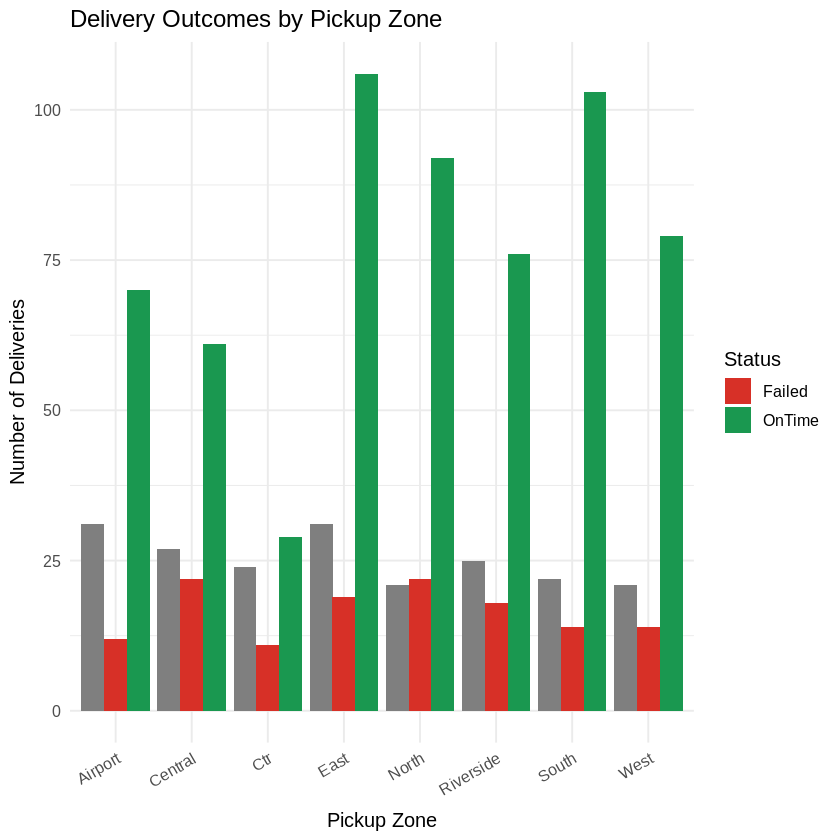

In [ ]:
zone_status <- ops %>% group_by(pickup_zone, delivery_status) %>%
  summarise(count=n(), .groups='drop')
p1 <- ggplot(zone_status, aes(x=pickup_zone, y=count, fill=delivery_status)) +
  geom_bar(stat='identity', position='dodge') +
  scale_fill_manual(values=c('Failed'='#d73027','Late'='#fee08b','OnTime'='#1a9850')) +
  labs(title='Delivery Outcomes by Pickup Zone',
       x='Pickup Zone', y='Number of Deliveries', fill='Status') +
  theme_minimal(base_size=12) +
  theme(axis.text.x=element_text(angle=30, hjust=1))
print(p1)
ggsave('r_fig1_zone_status.png', plot=p1, width=10, height=5, dpi=150)

## 2.3 Visualisation 2 - Rating Distribution by Delivery Status

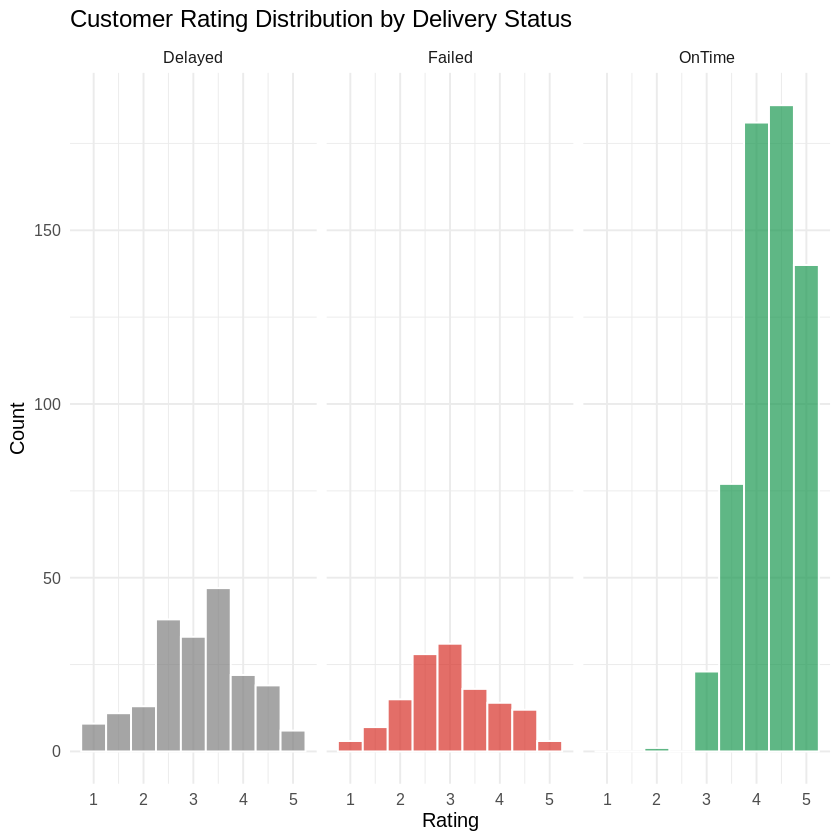

In [ ]:
p2 <- ggplot(ops[!is.na(ops$customer_rating_post_delivery),],
             aes(x=customer_rating_post_delivery, fill=delivery_status)) +
  geom_histogram(binwidth=0.5, alpha=0.7, colour='white') +
  facet_wrap(~delivery_status, ncol=3) +
  scale_fill_manual(values=c('OnTime'='#1a9850','Late'='#fdae61','Failed'='#d73027')) +
  labs(title='Customer Rating Distribution by Delivery Status',
       x='Rating', y='Count') + theme_minimal(base_size=12) + theme(legend.position='none')
print(p2)
ggsave('r_fig2_ratings.png', plot=p2, width=12, height=4, dpi=150)

## 2.4 Visualisation 3 - Correlation Heatmap

Correlation matrix:
                              customer_rating_post_delivery fuel_or_charge_cost
customer_rating_post_delivery                         1.000              -0.059
fuel_or_charge_cost                                  -0.059               1.000
route_distance_km                                     0.029               0.527
manual_route_override_count                          -0.060               0.099
proof_of_completion_missing                          -0.218               0.057
                              route_distance_km manual_route_override_count
customer_rating_post_delivery             0.029                      -0.060
fuel_or_charge_cost                       0.527                       0.099
route_distance_km                         1.000                       0.199
manual_route_override_count               0.199                       1.000
proof_of_completion_missing               0.022                       0.041
                              proof_of_compl

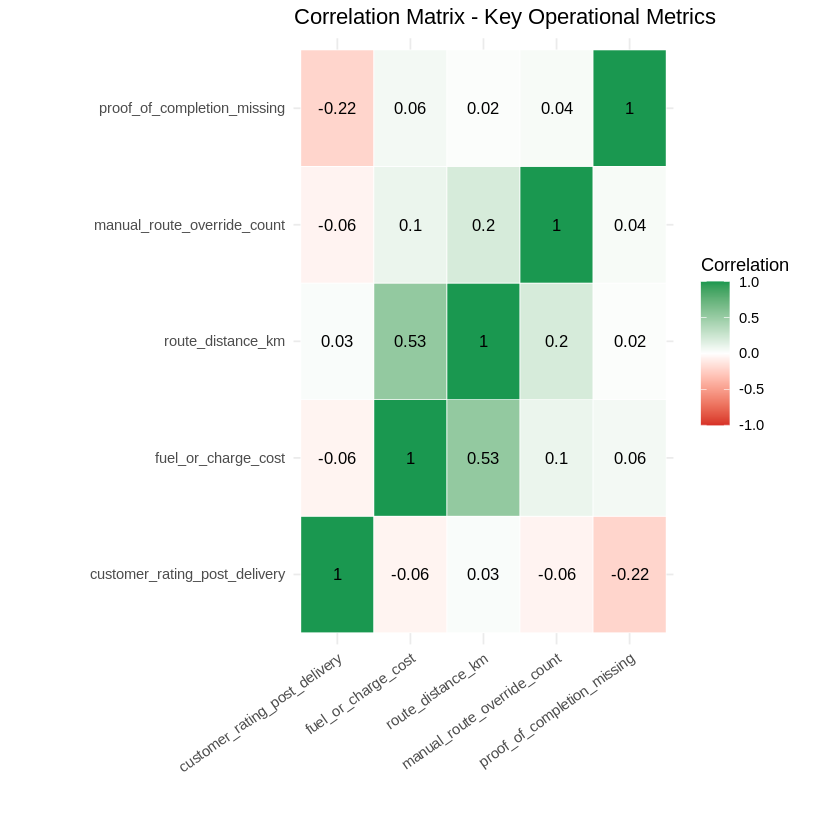

In [ ]:
corr_data <- ops %>%
  select(customer_rating_post_delivery, fuel_or_charge_cost,
         route_distance_km, manual_route_override_count,
         proof_of_completion_missing) %>% na.omit()
corr_mat <- cor(corr_data)
cat('Correlation matrix:\n'); print(round(corr_mat,3))
corr_df <- as.data.frame(as.table(corr_mat))
names(corr_df) <- c('Var1','Var2','Correlation')
p3 <- ggplot(corr_df, aes(x=Var1, y=Var2, fill=Correlation)) +
  geom_tile(colour='white') +
  geom_text(aes(label=round(Correlation,2)), size=3.5) +
  scale_fill_gradient2(low='#d73027',mid='white',high='#1a9850',midpoint=0,limits=c(-1,1)) +
  labs(title='Correlation Matrix - Key Operational Metrics', x='', y='') +
  theme_minimal(base_size=11) + theme(axis.text.x=element_text(angle=35,hjust=1))
print(p3)
ggsave('r_fig3_correlation.png', plot=p3, width=8, height=7, dpi=150)

## 2.5 Visualisation 4 - Driver Training vs Failure Rate + Linear Regression

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forg


=== Linear Regression: Predicting Failure Rate ===

Call:
lm(formula = fail_rate ~ training_score + years_experience + 
    driver_rating, data = driver_ops)

Residuals:
    Min      1Q  Median      3Q     Max 
-27.602 -12.163  -4.993  10.032  85.763 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)       42.20468   16.41705   2.571  0.01106 * 
training_score     0.07853    0.11666   0.673  0.50181   
years_experience   0.99566    0.32441   3.069  0.00252 **
driver_rating    -10.30061    3.21196  -3.207  0.00162 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16.5 on 159 degrees of freedom
  (7 observations deleted due to missingness)
Multiple R-squared:  0.1082,	Adjusted R-squared:  0.09134 
F-statistic: 6.428 on 3 and 159 DF,  p-value: 0.0003892



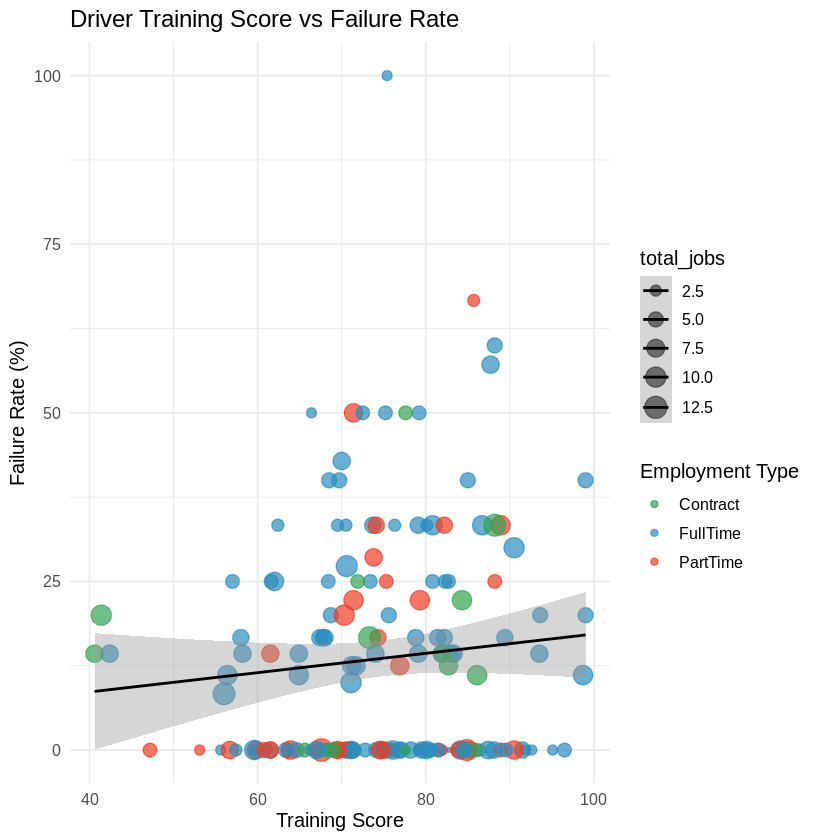

In [ ]:
driver_ops <- ops %>%
  group_by(driver_id) %>%
  summarise(total_jobs=n(), failed_jobs=sum(delivery_status=='Failed',na.rm=TRUE),
            .groups='drop') %>%
  mutate(fail_rate=failed_jobs/total_jobs*100) %>%
  left_join(drivers, by='driver_id')
p4 <- ggplot(driver_ops, aes(x=training_score, y=fail_rate,
                              colour=employment_type, size=total_jobs)) +
  geom_point(alpha=0.7) +
  geom_smooth(method='lm', se=TRUE, colour='black', linewidth=0.8) +
  scale_colour_manual(values=c('FullTime'='#2b8cbe','PartTime'='#f03b20','Contract'='#31a354')) +
  labs(title='Driver Training Score vs Failure Rate',
       x='Training Score', y='Failure Rate (%)', colour='Employment Type') +
  theme_minimal(base_size=12)
print(p4)
ggsave('r_fig4_driver_training.png', plot=p4, width=10, height=6, dpi=150)
model <- lm(fail_rate ~ training_score + years_experience + driver_rating, data=driver_ops)
cat('\n=== Linear Regression: Predicting Failure Rate ===\n')
print(summary(model))

## 2.6 Visualisation 5 - Monthly Complaint Trend

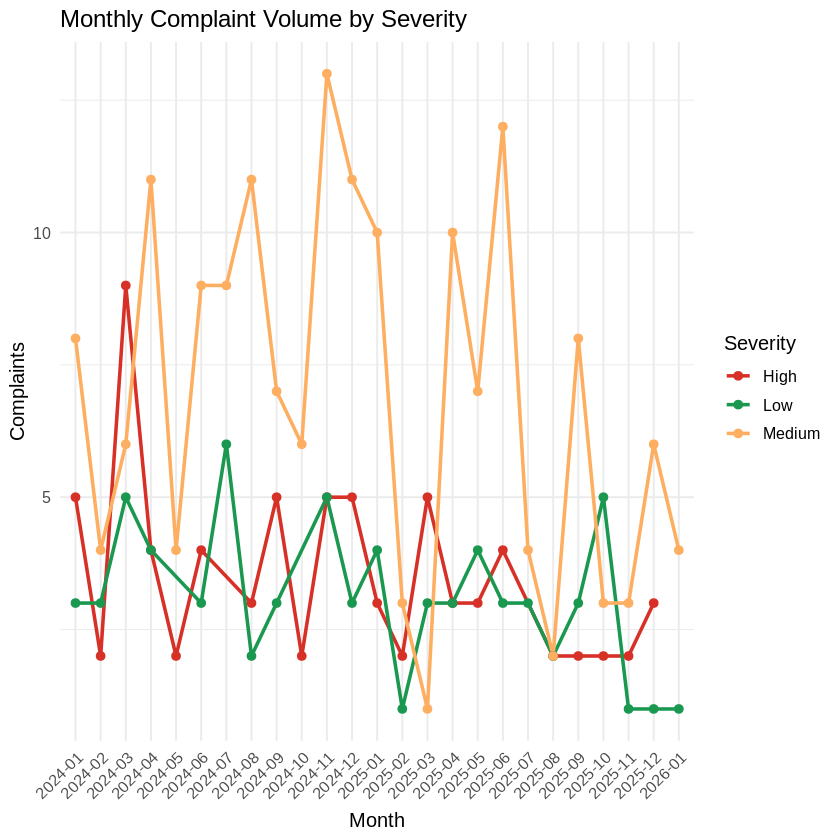

In [ ]:
complaints$month <- format(complaints$created_at, '%Y-%m')
comp_trend <- complaints %>% group_by(month, severity) %>%
  summarise(count=n(), .groups='drop') %>% filter(!is.na(month))
p5 <- ggplot(comp_trend, aes(x=month, y=count, colour=severity, group=severity)) +
  geom_line(linewidth=1) + geom_point(size=2) +
  scale_colour_manual(values=c('High'='#d73027','Medium'='#fdae61','Low'='#1a9850')) +
  labs(title='Monthly Complaint Volume by Severity',
       x='Month', y='Complaints', colour='Severity') +
  theme_minimal(base_size=12) + theme(axis.text.x=element_text(angle=45,hjust=1))
print(p5)
ggsave('r_fig5_complaint_trend.png', plot=p5, width=12, height=5, dpi=150)

## 2.7 Statistical Tests

In [ ]:
cat('=== T-Test: Rating OnTime vs Failed ===\n')
ontime_r <- deliveries$customer_rating_post_delivery[deliveries$delivery_status=='OnTime' &
              !is.na(deliveries$customer_rating_post_delivery)]
failed_r  <- deliveries$customer_rating_post_delivery[deliveries$delivery_status=='Failed' &
              !is.na(deliveries$customer_rating_post_delivery)]
t_result <- t.test(ontime_r, failed_r)
cat(sprintf('OnTime mean: %.3f | Failed mean: %.3f\n', mean(ontime_r), mean(failed_r)))
cat(sprintf('t = %.3f, p-value = %.6f\n', t_result$statistic, t_result$p.value))
cat(sprintf('Result: %s\n', ifelse(t_result$p.value < 0.05,
  'SIGNIFICANT - delivery failure significantly reduces customer rating.',
  'Not significant at 5% level.')))
cat('\n=== ANOVA: Failure Rate by Employment Type ===\n')
print(summary(aov(fail_rate ~ employment_type, data=driver_ops)))

=== T-Test: Rating OnTime vs Failed ===
OnTime mean: 4.283 | Failed mean: 3.049
t = 15.483, p-value = 0.000000
Result: SIGNIFICANT - delivery failure significantly reduces customer rating.

=== ANOVA: Failure Rate by Employment Type ===
                 Df Sum Sq Mean Sq F value Pr(>F)
employment_type   2    358   179.0   0.606  0.547
Residuals       167  49340   295.4               
